# $$Fine-tuning$$ $$for$$ $$classification$$

## Fine-Tuning for Classification

After building and loading a pretrained LLM, the next step is to adapt it to a specific downstream task. In this chapter, the model is fine-tuned for text classification, using spam detection as a concrete example.

- Fine-tuning adapts a general pretrained LLM to a specific task
- Classification fine-tuning maps input text → discrete labels
- Example task: spam vs. not spam message classification
- This chapter focuses on classification (not instruction-following)
- Pretrained weights are reused and slightly adjusted


<br/>

• Two main fine-tuning approaches:
  - Instruction fine-tuning (instruction + text → text)
  - Classification fine-tuning (text → label)

• Instruction fine-tuning:
  - Enables multi-task behavior
  - Basis of ChatGPT-style models

• Classification fine-tuning:
  - Task-specific
  - Simpler and more efficient


An instruction
fine-tuned model typically can undertake a broader range of tasks. We can view a clas
sification fine-tuned model as highly specialized, and generally, it is easier to develop a
specialized model than a generalist model that works well across various tasks.

## Choosing the Right Fine-Tuning Approach

#### Instruction fine-tuning

- Handles diverse, instruction-based tasks
- More flexible and interactive
- Requires large datasets and high compute

#### Classification fine-tuning

- Predicts predefined labels
- Precise and efficient
- Requires less data and compute
- Limited to trained classes

#### Key trade-off

- Versatility vs. efficiency

### Preparing the Dataset
- Modify and fine-tune the pretrained GPT model for classification
- First step: download and prepare the dataset
- Dataset type: text messages
- Labels: spam / non-spam
- Goal: build an intuitive example of classification fine-tuning

<div style="text-align: center; margin-top: 20px;">
  <img 
    src="https://raw.githubusercontent.com/salavii/llm-from-scratch/main/images/fine_tuning.png"
    style="width: 750px; border-radius: 10px; display: block; margin-left: auto; margin-right: auto;"
  >


## NOTE 
**Text messages typically sent via phone**,**not email**. **However**, **the same steps also apply to email classification**, **and interested readers can find links to email spam classification datasets in appendix B**. 


**The first step is to download the dataset.**

In [1]:
import urllib.request
import zipfile
import os
from pathlib import Path

url = "https://archive.ics.uci.edu/static/public/228/sms+spam+collection.zip"
zip_path = "sms_spam_collection.zip"
extracted_path = "sms_spam_collection"
data_file_path = Path(extracted_path) / "SMSSpamCollection.tsv"


def download_and_unzip_spam_data(url, zip_path, extracted_path, data_file_path):

    if data_file_path.exists():
        print(f"{data_file_path} already exists. Skipping download and extraction.")
        return
    # Downloads the file
    with urllib.request.urlopen(url) as response:
        with open(zip_path, "wb") as out_file:
            out_file.write(response.read())

    # Unzips the file
    with zipfile.ZipFile(zip_path, "r") as zip_ref:
        zip_ref.extractall(extracted_path)

    # Adds a .tsv file extension
    original_file_path = Path(extracted_path) / "SMSSpamCollection"
    os.rename(original_file_path, data_file_path)

    print(f"File downloaded and saved as {data_file_path}")

download_and_unzip_spam_data(url, zip_path, extracted_path, data_file_path)

sms_spam_collection\SMSSpamCollection.tsv already exists. Skipping download and extraction.


In [2]:
import pandas as pd
df = pd.read_csv(
    data_file_path, sep="\t", header=None, names=["Label", "Text"]
)
df


,Label,Text
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."
...,...,...
5567,spam,This is the 2nd time we have tried 2 contact u...
5568,ham,Will ü b going to esplanade fr home?
5569,ham,"Pity, * was in mood for that. So...any other s..."
5570,ham,The guy did some bitching but I acted like i'd...


Let’s examine the class label distribution:

In [3]:
print(df['Label'].value_counts())

Label
ham     4825
spam     747
Name: count, dtype: int64


### Dataset Balancing (Undersampling)

- Dataset is imbalanced (ham > spam)
- Use undersampling to balance classes
- Keep 747 samples per class

- Goal:
    - Smaller dataset
    - Faster LLM fine-tuning

In [4]:
def create_balanced_dataset(df):
    num_spam = df[df['Label'] == 'spam'].shape[0]
    ham_subset = df[df['Label'] == 'ham'].sample(num_spam, random_state=123)

    balanced_df = pd.concat([
        ham_subset, df[df['Label'] == 'spam']
    ])
    return balanced_df

In [5]:
balanced_df = create_balanced_dataset(df)
print(balanced_df["Label"].value_counts())

Label
ham     747
spam    747
Name: count, dtype: int64


Next, we convert the “string” class labels "ham" and "spam" into integer class labels 0
and 1, respectively:

In [6]:
balanced_df["Label"] = balanced_df["Label"].map({"ham": 0, "spam": 1})


 Next, we create a random_split function to split the dataset into three parts: 70%
for training, 10% for validation, and 20% for testing.

In [7]:
def random_split(df, train_frac, validation_frac):
   
    # Shuffle the entire DataFrame to remove any ordering bias
    # frac=1 means shuffle 100% of the rows
    df = df.sample(frac=1, random_state=123).reset_index(drop=True)

    # Compute the index where the training split ends
    train_end = int(len(df) * train_frac)

    validation_end = train_end + int(len(df) * validation_frac)

    # Split the DataFrame into train, validation, and test sets
    train_df = df[:train_end]
    validation_df = df[train_end:validation_end]
    test_df = df[validation_end:]

    return train_df, validation_df, test_df

train_df, validation_df, test_df = random_split(
    balanced_df, 0.7, 0.1
)

Let’s save the dataset as CSV (comma-separated value) files so we can reuse it later:


In [8]:
train_df.to_csv("train.csv", index=None)
validation_df.to_csv("validation.csv", index=None)
test_df.to_csv("test.csv", index=None)


Thus far, we have downloaded the dataset, balanced it, and split it into training and
evaluation subsets. Now we will set up the PyTorch data loaders that will be used to
train the model.

## Creating Data Loaders (Padding Strategy)
- Text messages have variable lengths
- Batching requires fixed-length inputs
- Two options:
    - Truncation → cheaper, but loses information ❌
    - adding → preserves all content ✅

Chosen approach:
- Pad all messages to the length of the longest message

Padding token:

- <|endoftext|>
- Token ID = 50256

Padding is applied at the token ID level, not as raw text

In [9]:
import tiktoken
tokenizer = tiktoken.get_encoding("gpt2")
print(tokenizer.encode("<|endoftext|>", allowed_special={"<|endoftext|>"}))

[50256]


We first need to implement a PyTorch Dataset, which specifies how the data is
loaded and processed before we can instantiate the data loaders. For this purpose,
we define the SpamDataset class, which implements the concepts in figure 6.6. This
SpamDataset class handles several key tasks: it identifies the longest sequence in the
training dataset, encodes the text messages, and ensures that all other sequences are
padded with a padding token to match the length of the longest sequence

In [10]:
import torch
from torch.utils.data import Dataset
import pandas as pd

class SpamDataset(Dataset):
    def __init__(self, csv_file, tokenizer, max_length=None, pad_token_id=50256):
        self.data = pd.read_csv(csv_file)

        # Pre-tokenize all texts once
        self.encoded_texts = [
            tokenizer.encode(text) for text in self.data["Text"]
        ]

        # Decide max_length
        if max_length is None:
            self.max_length = self._longest_encoded_length()
        else:
            self.max_length = max_length
            # Truncate only if a max_length is explicitly provided
            self.encoded_texts = [
                enc[:self.max_length] for enc in self.encoded_texts
            ]

        # Pad to max_length
        self.encoded_texts = [
            enc + [pad_token_id] * (self.max_length - len(enc))
            for enc in self.encoded_texts
        ]

    def __getitem__(self, index):
        encoded = self.encoded_texts[index]
        label = self.data.iloc[index]["Label"]
        return (
            torch.tensor(encoded, dtype=torch.long),
            torch.tensor(label, dtype=torch.long)
        )

    def __len__(self):
        return len(self.data)

    def _longest_encoded_length(self):
        return max(len(enc) for enc in self.encoded_texts)


### SpamDataset Length Handling
SpamDataset:
- loads CSV data
- tokenizes text with GPT-2 tokenizer
- pads or truncates sequences to a fixed length

Training set:
- max_length=None
- longest sequence length inferred from training data
- stored in train_dataset.max_length

In [11]:
train_dataset = SpamDataset(
    csv_file="train.csv",
    max_length=None,
    tokenizer=tokenizer
)

In [12]:
print(train_dataset.max_length)


120


Validation & Test sets:
- padded to training max length
- sequences longer than training max length are truncated

Model constraints:
- GPT context length = 1024 tokens
- use max_length=1024 if dataset contains longer texts

In [13]:
val_dataset = SpamDataset(
    csv_file="validation.csv",
    max_length=train_dataset.max_length,
    tokenizer=tokenizer
)

test_dataset = SpamDataset(
    csv_file="test.csv",
    max_length=train_dataset.max_length,
    tokenizer=tokenizer
)

Using the datasets as inputs, we can instantiate the data loaders similarly to when we
were working with text data. However, in this case, the targets represent class labels
rather than the next tokens in the text. For instance, if we choose a batch size of 8,
each batch will consist of eight training examples of length 120 and the correspond
ing class label of each example.

The code in the following listing creates the training, validation, and test set data load
ers that load the text messages and labels in batches of size 8.

In [14]:
from torch.utils.data import DataLoader

num_workers = 0     
batch_size = 8
torch.manual_seed(123)

train_loader = DataLoader(
    dataset=train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=num_workers,
    drop_last=True,
)

val_loader = DataLoader(
    dataset=val_dataset,
    batch_size=batch_size,
    num_workers=num_workers,
    drop_last=False,
)

test_loader = DataLoader(
    dataset=test_dataset,
    batch_size=batch_size,
    num_workers=num_workers,
    drop_last=False,
)

To ensure that the data loaders are working and are, indeed, returning batches of the
expected size, we iterate over the training loader and then print the tensor dimen
sions of the last batch:

In [15]:
for input_batch, target_batch in train_loader:
    pass
print("Input batch dimensions:", input_batch.shape)
print("Label batch dimensions", target_batch.shape)


Input batch dimensions: torch.Size([8, 120])
Label batch dimensions torch.Size([8])


In [16]:
print(f"{len(train_loader)} training batches")
print(f"{len(val_loader)} validation batches")
print(f"{len(test_loader)} test batches")


130 training batches
19 validation batches
38 test batches


# Initializing a model with pretrained weights

## Model Configuration Reuse

- Use the same model configuration as in pretraining
- Ensures compatibility with pretrained weights
- Model architecture remains unchanged
- Only the training objective changes:
    - From language modeling
    - To text classification

In [17]:
CHOOSE_MODEL = "gpt2-small (124M)"
INPUT_PROMPT = "Every effort moves"

BASE_CONFIG = {
    "vocab_size": 50257,         
    "context_length": 1024,      
    "drop_rate": 0.0,            
    "qkv_bias": True             
}
model_configs = {
    "gpt2-small (124M)": {"emb_dim": 768, "n_layers": 12, "n_heads": 12},
    "gpt2-medium (355M)": {"emb_dim": 1024, "n_layers": 24, "n_heads": 16},
    "gpt2-large (774M)": {"emb_dim": 1280, "n_layers": 36, "n_heads": 20},
    "gpt2-xl (1558M)": {"emb_dim": 1600, "n_layers": 48, "n_heads": 25},
}
BASE_CONFIG.update(model_configs[CHOOSE_MODEL])

Next, we import the download_and_load_gpt2 function from the gpt_download.py
file and reuse the GPTModel class and load_weights_into_gpt function from pretrain
ing (see chapter 5) to load the downloaded weights into the GPT model

In [18]:
from gpt_download import download_and_load_gpt2
from Attention import GPTModel, load_weights_into_gpt

model_size = CHOOSE_MODEL.split(" ")[-1].lstrip("(").rstrip(")")
settings, params = download_and_load_gpt2(
    model_size=model_size, models_dir="gpt2"
)
model = GPTModel(BASE_CONFIG)
load_weights_into_gpt(model, params)
model.eval()

File already exists and is up-to-date: gpt2\124M\checkpoint
File already exists and is up-to-date: gpt2\124M\encoder.json
File already exists and is up-to-date: gpt2\124M\hparams.json
File already exists and is up-to-date: gpt2\124M\model.ckpt.data-00000-of-00001
File already exists and is up-to-date: gpt2\124M\model.ckpt.index
File already exists and is up-to-date: gpt2\124M\model.ckpt.meta
File already exists and is up-to-date: gpt2\124M\vocab.bpe


GPTModel(
  (tok_emb): Embedding(50257, 768)
  (pos_emb): Embedding(1024, 768)
  (drop_emb): Dropout(p=0.0, inplace=False)
  (trf_blocks): Sequential(
    (0): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features=768, out_features=768, bias=True)
        (W_key): Linear(in_features=768, out_features=768, bias=True)
        (W_value): Linear(in_features=768, out_features=768, bias=True)
        (out_proj): Linear(in_features=768, out_features=768, bias=True)
        (dropout): Dropout(p=0.0, inplace=False)
      )
      (ff): FeedForward(
        (layers): Sequential(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): GELU()
          (2): Linear(in_features=3072, out_features=768, bias=True)
        )
      )
      (norm1): LayerNorm()
      (norm2): LayerNorm()
      (drop_shortcut): Dropout(p=0.0, inplace=False)
    )
    (1): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features=7

After loading the model weights into the GPTModel, we reuse the text generation util
ity function from chapters 4 and 5 to ensure that the model generates coherent text:

In [19]:
from Attention import generate_text_simple, token_ids_to_text, text_to_token_ids
text_1 = "Every effort moves you"

token_ids = generate_text_simple(
    model=model,
    idx= text_to_token_ids(text_1, tokenizer),
    max_new_tokens=15,
    context_size= BASE_CONFIG["context_length"]
)

print(token_ids_to_text(token_ids, tokenizer)) 

Every effort moves you forward.

The first step is to understand the importance of your work


Before we start fine-tuning the model as a spam classifier, let’s see whether the model
already classifies spam messages by prompting it with instructions:

In [20]:
text_2 = (
    "Is the following text 'spam'? Answer with 'yes' or 'no':"
    " 'You are a winner you have been specially"
    " selected to receive $1000 cash or a $2000 award.'"
)
token_ids = generate_text_simple(
    model=model,
    idx=text_to_token_ids(text_2, tokenizer),
    max_new_tokens=23,
    context_size=BASE_CONFIG["context_length"]
)
print(token_ids_to_text(token_ids, tokenizer))

Is the following text 'spam'? Answer with 'yes' or 'no': 'You are a winner you have been specially selected to receive $1000 cash or a $2000 award.'

The following text 'spam'? Answer with 'yes' or 'no': 'You are a winner


<br/>

Based on the output, it’s apparent that the model is struggling to follow instructions.
This result is expected, as it has only undergone pretraining and lacks instruction
fine-tuning. So, let’s prepare the model for classification fine-tuning.

## Adding a classification head

Fine-tuning for classification modifies a pretrained GPT model to predict class labels instead of next tokens. The original vocabulary-sized output layer is replaced with a smaller classification head whose size equals the number of classes (two for spam vs. not spam). Using two output nodes allows standard cross-entropy loss and generalizes easily to multi-class tasks while reusing pretrained weights.

In [21]:
print(model)

GPTModel(
  (tok_emb): Embedding(50257, 768)
  (pos_emb): Embedding(1024, 768)
  (drop_emb): Dropout(p=0.0, inplace=False)
  (trf_blocks): Sequential(
    (0): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features=768, out_features=768, bias=True)
        (W_key): Linear(in_features=768, out_features=768, bias=True)
        (W_value): Linear(in_features=768, out_features=768, bias=True)
        (out_proj): Linear(in_features=768, out_features=768, bias=True)
        (dropout): Dropout(p=0.0, inplace=False)
      )
      (ff): FeedForward(
        (layers): Sequential(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): GELU()
          (2): Linear(in_features=3072, out_features=768, bias=True)
        )
      )
      (norm1): LayerNorm()
      (norm2): LayerNorm()
      (drop_shortcut): Dropout(p=0.0, inplace=False)
    )
    (1): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features=7

To get the model ready for classification fine-tuning, we first freeze the model, meaning
that we make all layers nontrainable

In [22]:
for param in model.parameters():
    param.requires_grad = False

Then, we replace the output layer (model.out_head), which originally maps the layer
inputs to 50,257 dimensions, the size of the vocabulary

In [23]:
torch.manual_seed(123)
num_classes = 2

model.out_head = torch.nn.Linear(
    in_features=BASE_CONFIG["emb_dim"],
    out_features=num_classes
)

To fine-tune a pretrained **GPT-2**** model for classification, the original **vocabulary-sized output layer** is replaced with a **small classification head** whose output dimension matches the number of classes (e.g., 2 for spam detection). The head uses `BASE_CONFIG["emb_dim"]` as input so the same code works across different GPT-2 sizes.

The new output layer is **trainable by default** and can already perform basic classification. However, better results are achieved by additionally **fine-tuning** the **final Transformer** block and the final LayerNorm, which are closest to the output and capture **task-specific** patterns, while keeping the lower layers frozen to preserve pretrained language knowledge and reduce computation

In [24]:
for param in model.trf_blocks[-1].parameters():
    param.requires_grad = True
for param in model.final_norm.parameters():
    param.requires_grad = True

In [25]:
inputs = tokenizer.encode("Do you have time")
inputs = torch.tensor(inputs).unsqueeze(0)
print("Inputs:", inputs)
print("Inputs dimensions:", inputs.shape)  

Inputs: tensor([[5211,  345,  423,  640]])
Inputs dimensions: torch.Size([1, 4])


In [26]:
with torch.no_grad():
    outputs = model(inputs)
print("Outputs:\n", outputs)
print("Outputs dimensions:", outputs.shape)

Outputs:
 tensor([[[-1.5854,  0.9904],
         [-3.7234,  7.4548],
         [-2.2660,  6.6049],
         [-3.5983,  3.9901]]])
Outputs dimensions: torch.Size([1, 4, 2])


In [27]:
print("Last output token:", outputs[:, -1, :])

Last output token: tensor([[-3.5983,  3.9901]])


- After replacing the GPT output layer, the model output shape changes from `[batch, seq_len, vocab_size]` to`[batch, seq_len, num_classes]`.
- The **number of output** rows still matches the number of input tokens, but each row now contains class logits instead of vocabulary **logits.**
- For text classification, we do **not** need predictions for every token.
- The **last token’s output** is used as a summary representation of the entire input sequence.
- The final classification decision **(e.g., spam vs. not spam)** is made using only the last output row.
- This approach aligns with the autoregressive nature of GPT, where the final token has access to the full context of the input text.

GPT uses causal attention, where each token can only attend to itself and the tokens that come before it. As a result, the last token has access to the full context of the input sequence. Therefore, for text classification tasks, only the last output token is used to make the final class prediction.

# Calculating the classification loss and accuracy
Only one small task remains before we fine-tune the model: we must implement the
model evaluation functions used during fine-tuning

In [28]:
logits = outputs[:, -1, :]
label = torch.argmax(logits)
print("Class label:", label.item())

Class label: 1


This concept can be used to compute the classification accuracy, which measures the
percentage of correct predictions across a dataset.
 To determine the classification accuracy, we apply the argmax-based prediction
code to all examples in the dataset and calculate the proportion of correct predictions
by defining a calc_accuracy_loader function.

In [29]:
def calc_accuracy_loader(data_loader, model, device, num_batches=None):
    model.eval()
    correct_predictions, num_examples = 0, 0
    
    if num_batches is None:
        num_batches = len(data_loader)
    else:
        num_batches = min(num_batches, len(data_loader))
    
    
    for i, (input_batch, target_batch) in enumerate(data_loader):
        if i < num_batches:
            input_batch = input_batch.to(device)
            target_batch = target_batch.to(device)
            
            with torch.no_grad():
                logits = model(input_batch)[:, -1, :]    
            
            predicted_labels = torch.argmax(logits, dim=-1)
            num_examples += predicted_labels.shape[0]
            correct_predictions += (predicted_labels == target_batch).sum().item()
        
        else:
            break
    return correct_predictions / num_examples

Let’s use the function to determine the classification accuracies across various datasets
estimated from 10 batches for efficiency:

In [30]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
torch.manual_seed(123)

train_accuracy = calc_accuracy_loader(
    train_loader, model, device, num_batches=10
)

val_accuracy = calc_accuracy_loader(
    val_loader, model, device, num_batches=10
)

test_accuracy = calc_accuracy_loader(
    test_loader, model, device, num_batches=10
)

print(f"Training accuracy: {train_accuracy*100:.2f}%")
print(f"Validation accuracy: {val_accuracy*100:.2f}%")
print(f"Test accuracy: {test_accuracy*100:.2f}%")

Training accuracy: 46.25%
Validation accuracy: 45.00%
Test accuracy: 48.75%


In [31]:
def calc_loss_batch(input_batch, target_batch, model, device):
    input_batch = input_batch.to(device)
    target_batch = target_batch.to(device)
    logits = model(input_batch)[:, -1, :]
    loss = torch.nn.functional.cross_entropy(logits, target_batch)
    return loss

We use the calc_loss_batch function to compute the loss for a single batch obtained
from the previously defined data loaders. To calculate the loss for all batches in a data
loader, we define the calc_loss_loader function as before.

In [32]:
def calc_loss_loader(data_loader, model, device, num_batches=None):
    total_loss = 0.
    if len(data_loader) == 0:
        return float("nan")
    elif num_batches is None:
        num_batches = len(data_loader)
    else:                                       
        num_batches = min(num_batches, len(data_loader))
    
    for i, (input_batch, target_batch) in enumerate(data_loader):
        if i < num_batches:
            loss = calc_loss_batch(
                input_batch, target_batch, model, device
                                    )
            total_loss += loss.item()
        else:
            break
    return total_loss / num_batches

In [33]:
with torch.no_grad():                
    train_loss = calc_loss_loader(
        train_loader, model, device, num_batches=5
                                 )
    val_loss = calc_loss_loader(val_loader, model, device, num_batches=5)
    test_loss = calc_loss_loader(test_loader, model, device, num_batches=5)

print(f"Training loss: {train_loss:.3f}")
print(f"Validation loss: {val_loss:.3f}")
print(f"Test loss: {test_loss:.3f}")

Training loss: 2.453
Validation loss: 2.583
Test loss: 2.322


# Fine-tuning the model on supervised data
During supervised fine-tuning, we use a standard PyTorch training loop similar to pretraining. Each epoch processes the entire training dataset in batches. For every batch, we reset gradients, compute the classification loss on the last token, backpropagate gradients, and update the trainable weights. Instead of tracking generated text quality, we track training loss and classification accuracy. Progress is measured by the number of training examples seen rather than tokens, since the goal is correct label prediction (spam vs. not spam).

In [39]:
def train_classifier_simple(model, train_loader, val_loader, 
                            optimizer, device, num_epochs, eval_freq, eval_iter):

    train_losses, val_losses, train_accs, val_accs = [], [], [], []
    examples_seen, global_step = 0, -1

    for epoch in range(num_epochs):
        model.train()

        for input_batch, target_batch in train_loader:
            optimizer.zero_grad()
            loss = calc_loss_batch(
                input_batch, target_batch, model, device
            )

            loss.backward()
            optimizer.step()
            examples_seen += input_batch.shape[0]
            global_step += 1

            if global_step % eval_freq == 0:
                train_loss, val_loss = evaluate_model(
                                    model, train_loader, val_loader, device, eval_iter
                                                     )
   
                train_losses.append(train_loss)
                val_losses.append(val_loss)
                print(f"Ep {epoch+1} (Step {global_step:06d}): "
                f"Train loss {train_loss:.3f}, "
                f"Val loss {val_loss:.3f}")

        train_accuracy = calc_accuracy_loader(
                                    train_loader, model, device, num_batches=eval_iter
                                            )
        val_accuracy = calc_accuracy_loader(
                                    val_loader, model, device, num_batches=eval_iter
                                            )
            
        print(f"Training accuracy: {train_accuracy*100:.2f}% | ", end="")
        print(f"Validation accuracy: {val_accuracy*100:.2f}%")
        train_accs.append(train_accuracy)
        val_accs.append(val_accuracy)

    return train_losses, val_losses, train_accs, val_accs, examples_seen

The evaluate_model function is identical to the one we used for pretraining

In [40]:
def evaluate_model(model, train_loader, val_loader, device, eval_iter):
    model.eval()
    with torch.no_grad():
        train_loss = calc_loss_loader(
            train_loader, model, device, num_batches=eval_iter
        )
        val_loss = calc_loss_loader(
            val_loader, model, device, num_batches=eval_iter
        )

    model.train()
    return train_loss, val_loss

In [41]:
import time
start_time = time.time()
torch.manual_seed(123)

optimizer = torch.optim.AdamW(model.parameters(), lr=5e-5, weight_decay=0.1)
num_epochs = 5

train_losses, val_losses, train_accs, val_accs, examples_seen = \
    train_classifier_simple(
                        model, train_loader, val_loader, optimizer, device,
                        num_epochs=num_epochs, eval_freq=50, eval_iter=5
                            )

end_time = time.time()
execution_time_minutes = (end_time - start_time) / 60
print(f"Training completed in {execution_time_minutes:.2f} minutes.")

Ep 1 (Step 000000): Train loss 2.153, Val loss 2.392
Ep 1 (Step 000050): Train loss 0.617, Val loss 0.637
Ep 1 (Step 000100): Train loss 0.523, Val loss 0.557
Training accuracy: 70.00% | Validation accuracy: 72.50%
Ep 2 (Step 000150): Train loss 0.560, Val loss 0.488
Ep 2 (Step 000200): Train loss 0.419, Val loss 0.396
Ep 2 (Step 000250): Train loss 0.409, Val loss 0.353
Training accuracy: 82.50% | Validation accuracy: 85.00%
Ep 3 (Step 000300): Train loss 0.334, Val loss 0.320
Ep 3 (Step 000350): Train loss 0.343, Val loss 0.310
Training accuracy: 87.50% | Validation accuracy: 90.00%
Ep 4 (Step 000400): Train loss 0.159, Val loss 0.228
Ep 4 (Step 000450): Train loss 0.163, Val loss 0.143
Ep 4 (Step 000500): Train loss 0.226, Val loss 0.145
Training accuracy: 100.00% | Validation accuracy: 95.00%
Ep 5 (Step 000550): Train loss 0.208, Val loss 0.149
Ep 5 (Step 000600): Train loss 0.089, Val loss 0.076
Training accuracy: 100.00% | Validation accuracy: 97.50%
Training completed in 17.29 m

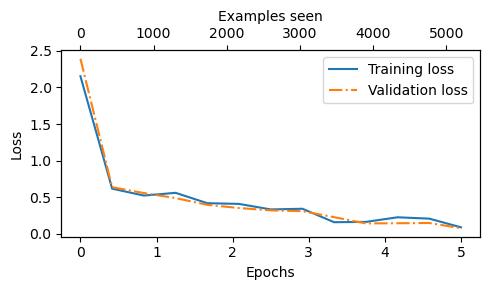

In [43]:
import matplotlib.pyplot as plt
def plot_values(
epochs_seen, examples_seen, train_values, val_values,
label="loss"):
    fig, ax1 = plt.subplots(figsize=(5, 3))
    ax1.plot(epochs_seen, train_values, label=f"Training {label}")
    ax1.plot(
            epochs_seen, val_values, linestyle="-.",
            label=f"Validation {label}"
    )
    ax1.set_xlabel("Epochs")
    ax1.set_ylabel(label.capitalize())
    ax1.legend()

    ax2 = ax1.twiny()
    ax2.plot(examples_seen, train_values, alpha=0)   
    ax2.set_xlabel("Examples seen")
    fig.tight_layout()            
    plt.savefig(f"{label}-plot.pdf")
    plt.show()

epochs_tensor = torch.linspace(0, num_epochs, len(train_losses))
examples_seen_tensor = torch.linspace(0, examples_seen, len(train_losses))
plot_values(epochs_tensor, examples_seen_tensor, train_losses, val_losses)

## Choosing the number of epochs 
Earlier, when we initiated the training, we set the number of epochs to five. The num
ber of epochs depends on the dataset and the task’s difficulty, and there is no uni
versal solution or recommendation, although an epoch number of five is usually a
good starting point. If the model overfits after the first few epochs as a loss plot (see
figure 6.16), you may need to reduce the number of epochs. Conversely, if the trend
line suggests that the validation loss could improve with further training, you should
increase the number of epochs. In this concrete case, five epochs is a reasonable
number as there are no signs of early overfitting, and the validation loss is close to 0.

Using the same plot_values function, let’s now plot the classification accuracies:

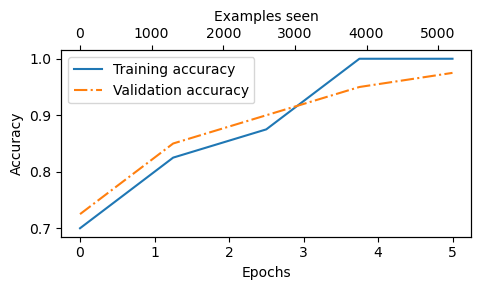

In [44]:
epochs_tensor = torch.linspace(0, num_epochs, len(train_accs))
examples_seen_tensor = torch.linspace(0, examples_seen, len(train_accs))
plot_values(
    epochs_tensor, examples_seen_tensor, train_accs, val_accs,
    label="accuracy"
)

when using the train_classifier_simple function, which means our estimations of
training and validation performance are based on only five batches for efficiency
during training. 
 Now we must calculate the performance metrics for the training, validation, and
test sets across the entire dataset by running the following code, this time without
defining the eval_iter value:

In [45]:
train_accuracy = calc_accuracy_loader(train_loader, model, device)
val_accuracy = calc_accuracy_loader(val_loader, model, device)
test_accuracy = calc_accuracy_loader(test_loader, model, device)

print(f"Training accuracy: {train_accuracy*100:.2f}%")
print(f"Validation accuracy: {val_accuracy*100:.2f}%")
print(f"Test accuracy: {test_accuracy*100:.2f}%")


Training accuracy: 96.92%
Validation accuracy: 97.32%
Test accuracy: 96.00%


# Using the LLM as a spam classifier
Having fine-tuned and evaluated the model, we are now ready to classify spam mes
sages (see figure 6.18). Let’s use our fine-tuned GPT-based spam classification model.
The following classify_review function follows data preprocessing steps similar
to those we used in the SpamDataset implemented earlier. Then, after processing
text into token IDs, the function uses the model to predict an integer class label,
similar to what we implemented in section 6.6, and then returns the corresponding
class name.

In [47]:
model.pos_emb.weight.shape[0]

1024

In [49]:
def classify_review(
    text,
    model,
    tokenizer,
    device,
    max_length,
    pad_token_id=50256
):
    # 1) inference mode
    model.eval()

    # 2) tokenize text
    input_ids = tokenizer.encode(text)

    # 3) model context limit (e.g. 1024 for GPT-2)
    supported_context_length = model.pos_emb.weight.shape[0]

    # 4) final allowed length
    max_len = min(max_length, supported_context_length)

    # 5) truncate if too long
    input_ids = input_ids[:max_len]

    # 6) pad if too short
    input_ids += [pad_token_id] * (max_len - len(input_ids))

    # 7) to tensor + add batch dimension
    input_tensor = torch.tensor(input_ids, device=device).unsqueeze(0)

    # 8) forward pass (last token only)
    with torch.no_grad():
        logits = model(input_tensor)[:, -1, :]  # (1, 2)

    # 9) predict label
    predicted_label = torch.argmax(logits, dim=-1).item()

    # 10) map to class name
    return "spam" if predicted_label == 1 else "not spam"


Let’s try this classify_review function on an example text: 

In [58]:
text_1 = (
    "You are a winner you have been specially"
    " selected to receive $1000 cash or a $2000 award."
)
print(classify_review(
    text_1, model, tokenizer, device, max_length=train_dataset.max_length
))

spam


In [56]:
text_2 = (
    "Hey, just wanted to check if we're still on"
    " for dinner tonight? Let me know!"
)
print(classify_review(
    text_2, model, tokenizer, device, max_length=train_dataset.max_length
))

not spam


The model again makes a correct prediction and returns a “not spam” label.
 Finally, let’s save the model in case we want to reuse the model later without having
to train it again. We can use the torch.save method:

In [59]:
torch.save(model.state_dict(), "review_classifier.pth")

In [61]:
model_state_dict = torch.load("review_classifier.pth", map_location=device)
model.load_state_dict(model_state_dict)
model.eval()


GPTModel(
  (tok_emb): Embedding(50257, 768)
  (pos_emb): Embedding(1024, 768)
  (drop_emb): Dropout(p=0.0, inplace=False)
  (trf_blocks): Sequential(
    (0): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features=768, out_features=768, bias=True)
        (W_key): Linear(in_features=768, out_features=768, bias=True)
        (W_value): Linear(in_features=768, out_features=768, bias=True)
        (out_proj): Linear(in_features=768, out_features=768, bias=True)
        (dropout): Dropout(p=0.0, inplace=False)
      )
      (ff): FeedForward(
        (layers): Sequential(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): GELU()
          (2): Linear(in_features=3072, out_features=768, bias=True)
        )
      )
      (norm1): LayerNorm()
      (norm2): LayerNorm()
      (drop_shortcut): Dropout(p=0.0, inplace=False)
    )
    (1): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features=7